In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 0. Lectura de los df

Leemos los df del fichero `pickle` y lo cargamos en una variable `df` que será un pandas.Dataframe.

En nuestro caso como nuestros NIA´s acaban en 78 y 48 cargamos el fichero 26

$48 + 78 \pmod {100} = 26$ 

In [3]:
# Abre el archivo en modo lectura binaria ('rb')
with open('../data/bank_26.pkl', 'rb') as archivo:
    df = pickle.load(archivo)

C:\Users\aleja\AppData\Local\Temp\ipykernel_20140\3242033964.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(archivo)


### 1. Características Básicas de nuestro Dataset

En primer lugar, nuestro dataset contiene **11000** entradas (filas) y **17** atributos (columnas)

En esta salida también se puede observar el tipo de cada variable. Así pues, podemos concluir que:

| Variables Numéricas | Variables Categóricas |
|---------------------|-----------------------|
| age | job |
| balance | marital |
| day | education |
| duration| default |
| campaign| housing |
| pdays | loan |
| previous| contact |
|| month |
|| poutcome |
|| deposit |

Donde `deposit` es la variable a predecir, recordar que este problema es de **Clasificación binaria**, dado un cliente ¿contratará un Déposito (Si/No)?

Sin embargo, a partir de esta salida no podemos identificar las variables ordinales por lo que abrá que mirar con 'lupa' las variables categóricas para separarlas.

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 11000 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11000 non-null  int64 
 1   job        11000 non-null  object
 2   marital    10601 non-null  object
 3   education  11000 non-null  object
 4   default    11000 non-null  object
 5   balance    11000 non-null  int64 
 6   housing    11000 non-null  object
 7   loan       11000 non-null  object
 8   contact    11000 non-null  object
 9   day        11000 non-null  int64 
 10  month      11000 non-null  object
 11  duration   11000 non-null  int64 
 12  campaign   11000 non-null  int64 
 13  pdays      11000 non-null  int64 
 14  previous   11000 non-null  int64 
 15  poutcome   11000 non-null  object
 16  deposit    11000 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.5+ MB


#### ¿Cuáles de las variables categóricas anteriores son Ordinales?

Para contestar esta pregunta tendremos que ver valores que pueden tomar todos sus valores y analizar si algunos siguen una lógica de orden.

Existen dos variables susceptibles de ser consideradas ordinales `education` y `month`.

Cabe señalar que si se deseara hacer ordinal `education` habría que gestionar los valores 'unknown' de alguna forma porque sino no se estaría respetando la idea de orden.

In [33]:
for categorical in df.select_dtypes(exclude="number"):
    print(f"{categorical}: {df[categorical].unique()}\n")

job: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']

marital: ['married' None 'divorced' 'single']

education: ['secondary' 'tertiary' 'primary' 'unknown']

default: ['no' 'yes']

housing: ['yes' 'no']

loan: ['no' 'yes']

contact: ['unknown' 'cellular' 'telephone']

month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome: ['unknown' 'other' 'failure' 'success']

deposit: ['yes' 'no']



#### ¿Qué variables Categóricas cuentan con una alta cardinalidad?

Como se puede apreciar en la siguiente salida, los atributos `job` y `month` tienen una alta cardinalidad, tienen 12 valores posibles. Esto puede ser objeto de preprocesado y de realizar Feature Engineering.

In [24]:
df.select_dtypes(exclude='number').nunique()

job          12
marital       3
education     4
default       2
housing       2
loan          2
contact       3
month        12
poutcome      4
deposit       2
dtype: int64

Otra manera de verlo, es con esta métrica que recoge la proporción de valores únicos por columna entre el número total de filas.

In [25]:
df.select_dtypes(exclude='number').nunique() / df.shape[0] * 100

job          0.109091
marital      0.027273
education    0.036364
default      0.018182
housing      0.018182
loan         0.018182
contact      0.027273
month        0.109091
poutcome     0.036364
deposit      0.018182
dtype: float64

#### ¿El Dataset está desbalanceado?

Ahora, vamos a comprobar si el dataset está desbalanceado.

Como se puede observar en la siguiente salida el 47.45% de las entradas han sido clientes que **NO** han contratado un déposito mientras que el 52,55% han sido clientes que **SÍ** lo han hecho. 

Por lo tanto, parece haber un ligero desbalanceo, aunque en la fase de entrenamiento habrá que entrenar usando diferentes métricas (**Accuracy**, **Precision**, **Recall** y **F1-Score**) para comprobar que métrica nos reporta el mejor rendimiento.

En este caso, un Falso Positivo consiste en un cliente que no está dispuesto a contratar un depósito pero nuestro modelo considera que si por lo que se le aplicará una estrategia de promoción en vano.

Mientras, que un Falso Negativo consiste en un cliente que sí está dispuesto a contratar un depósito pero nuestro modelo considera que no por lo que no se le aplicará la estrategia de promoción más adecuada.

De este modo, desde la óptica de negocio de este problema parece que es más importante minimizar los Falsos Negativos considerando que no existen más costes asociados a cometer Falsos Positivos.

Esto quiere decir, que de las métricas mencionadas anteriormente podemos prescindir de **Precision** que es la que refleja los Falsos Positivos.

In [37]:
print(df['deposit'].value_counts())
print(f"\nClase YES: {round(len(df[df['deposit'] == 'yes'])/len(df)*100, 2)}%\nClase NO: {round(len(df[df['deposit'] == 'no'])/len(df)*100, 2)}%")

deposit
no     5780
yes    5220
Name: count, dtype: int64

Clase YES: 47.45%
Clase NO: 52.55%


#### Missing Values 

A continuación, se muestran los valores nulos que contiene nuestro dataset.

Solo existe un atributo que contiene valores nulos que es `marital`, un 3.63% de sus valores son nulos, por tanto habrá que tratarlo más adelante.

In [38]:
print(df.isnull().sum())
print(f"\n% de Valores Nulos del Atributo Marital: {round(df['marital'].isnull().sum()/len(df['marital']) * 100, 2)}%")

age            0
job            0
marital      399
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day            0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
deposit        0
dtype: int64

% de Valores Nulos del Atributo Marital: 3.63%


### 2. Análisis Univariante

En este apartado se realizará un análisis univariante de algunos atributos del dataset.

#### Pdays

Pdays es un atributo del dataset que refleja el número de días desde que este cliente fué contactacto en la campaña anterior. Si es -1 significa que no ha habido contacto o es desconocido.

La distribución de valores de este atributo es muy asimétrica un 74.57% de valores son -1, es decir, que el contacto es desconocido. Esto es muy problemático ya que este valor elimina el sentido de orden numérico que tienen el resto de valores por lo que habrá que preprocesarla de alguna forma para eliminar este problema

In [36]:
print(df['pdays'].value_counts())
print(f"\n% de Pdays == -1: {round(len(df[df['pdays'] == -1])/len(df)*100,2)}%")

pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
        ... 
 651       1
 214       1
 24        1
 701       1
 118       1
Name: count, Length: 472, dtype: int64

% de Pdays == -1: 74.57%


Text(0.5, 1.0, 'Distribución en Bruto de Pdays')

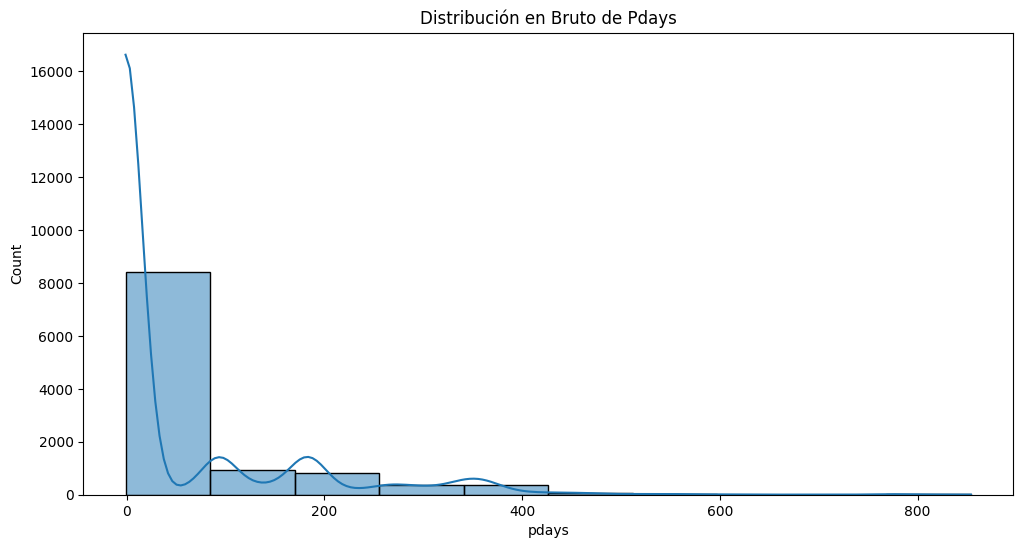

In [39]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='pdays',
    bins=10,
    kde=True
)
plt.title("Distribución en Bruto de Pdays")

#### Age

Text(0.5, 1.0, 'Distribución de Age')

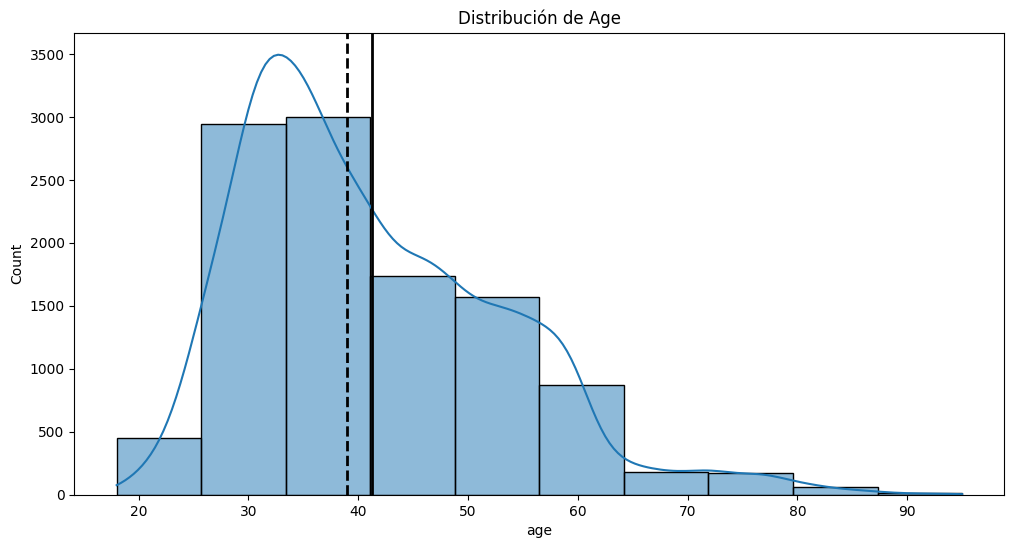

In [40]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='age',
    bins=10,
    kde=True
)
plt.axvline(x=df['age'].mean(), color="black", linewidth=2.0)
plt.axvline(x=df['age'].median(), color="black", linestyle="--", linewidth=2.0)
plt.title("Distribución de Age")

#### Balance

Text(0.5, 1.0, 'Distribución de Balance (percentiles 1-99)')

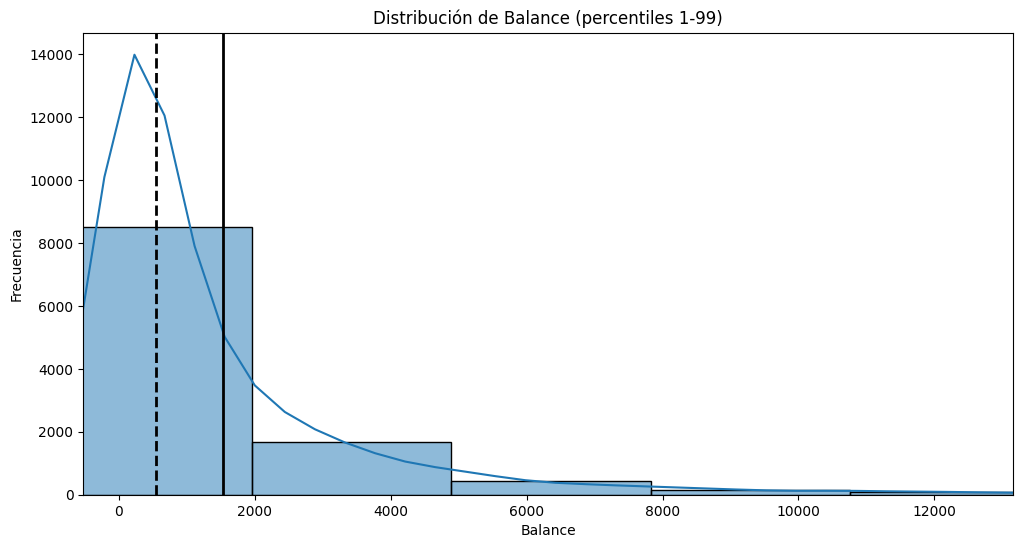

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='balance',
    bins=30,
    kde=True
)
plt.axvline(x=df['balance'].mean(), color="black", linewidth=2.0)
plt.axvline(x=df['balance'].median(), color="black", linestyle="--", linewidth=2.0)

# Ajustar la escala para mejor visualización
plt.xlim(df['balance'].quantile(0.01), df['balance'].quantile(0.99))
plt.xlabel('Balance')
plt.ylabel('Frecuencia')
plt.title('Distribución de Balance (percentiles 1-99)')

#### Job

Text(0.5, 1.0, 'Distribución de Job')

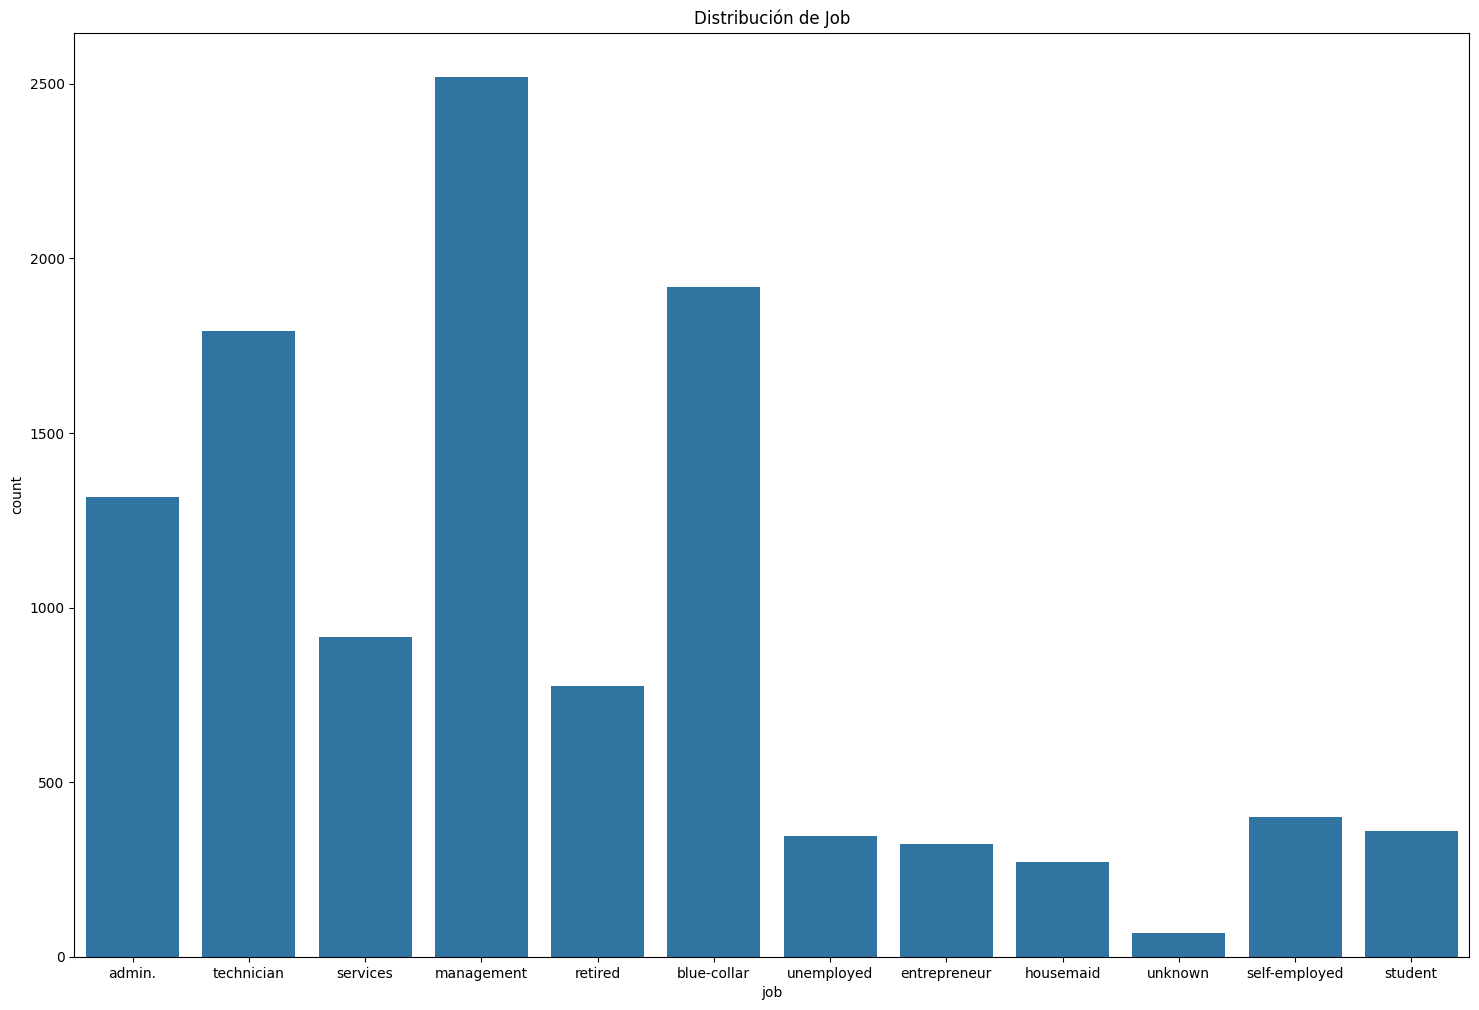

In [41]:
plt.figure(figsize=(18, 12))
sns.countplot(
    data=df,
    x='job'
)
plt.title("Distribución de Job")

### 3. Análisis Bivariante

En este apartado se estudiará la relación entre las variables entre sí y con respecto a la variable objetivo `deposit`.

#### Relación entre Variables Categóricas

##### Pdays vs. Deposit

TODO: Completar

In [ ]:
(df['pdays'] == -1).value_counts()

pdays
True     8203
False    2797
Name: count, dtype: int64

<Axes: xlabel='pdays', ylabel='Count'>

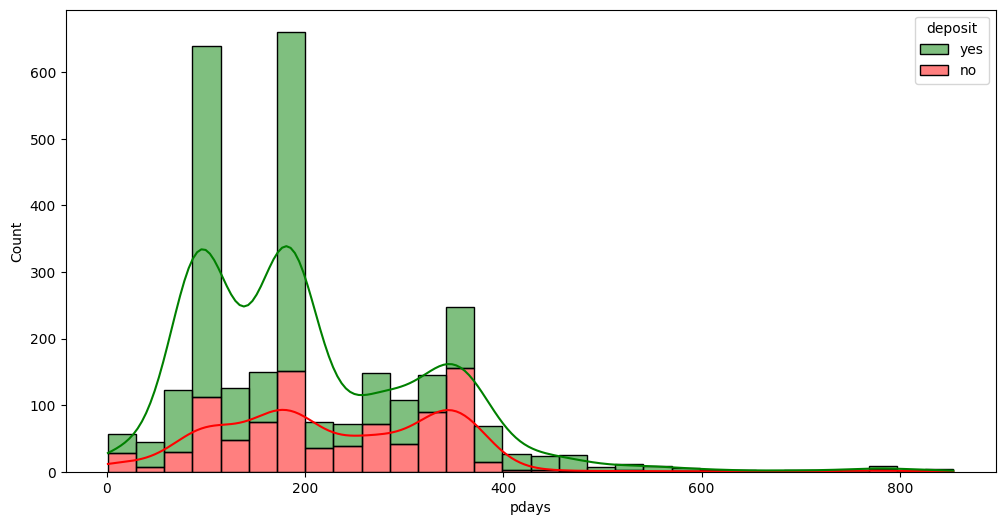

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df[df['pdays'] != -1],
    x='pdays',
    bins=30,
    kde=True,
    hue="deposit",
    multiple='stack',
    palette={'yes': 'green', 'no': 'red'}
)

#### Relación entre Variables Numéricas

Text(0.5, 1.0, 'Relación entre las variables numéricas entre sí y respecto a deposit')

<Figure size 1200x600 with 0 Axes>

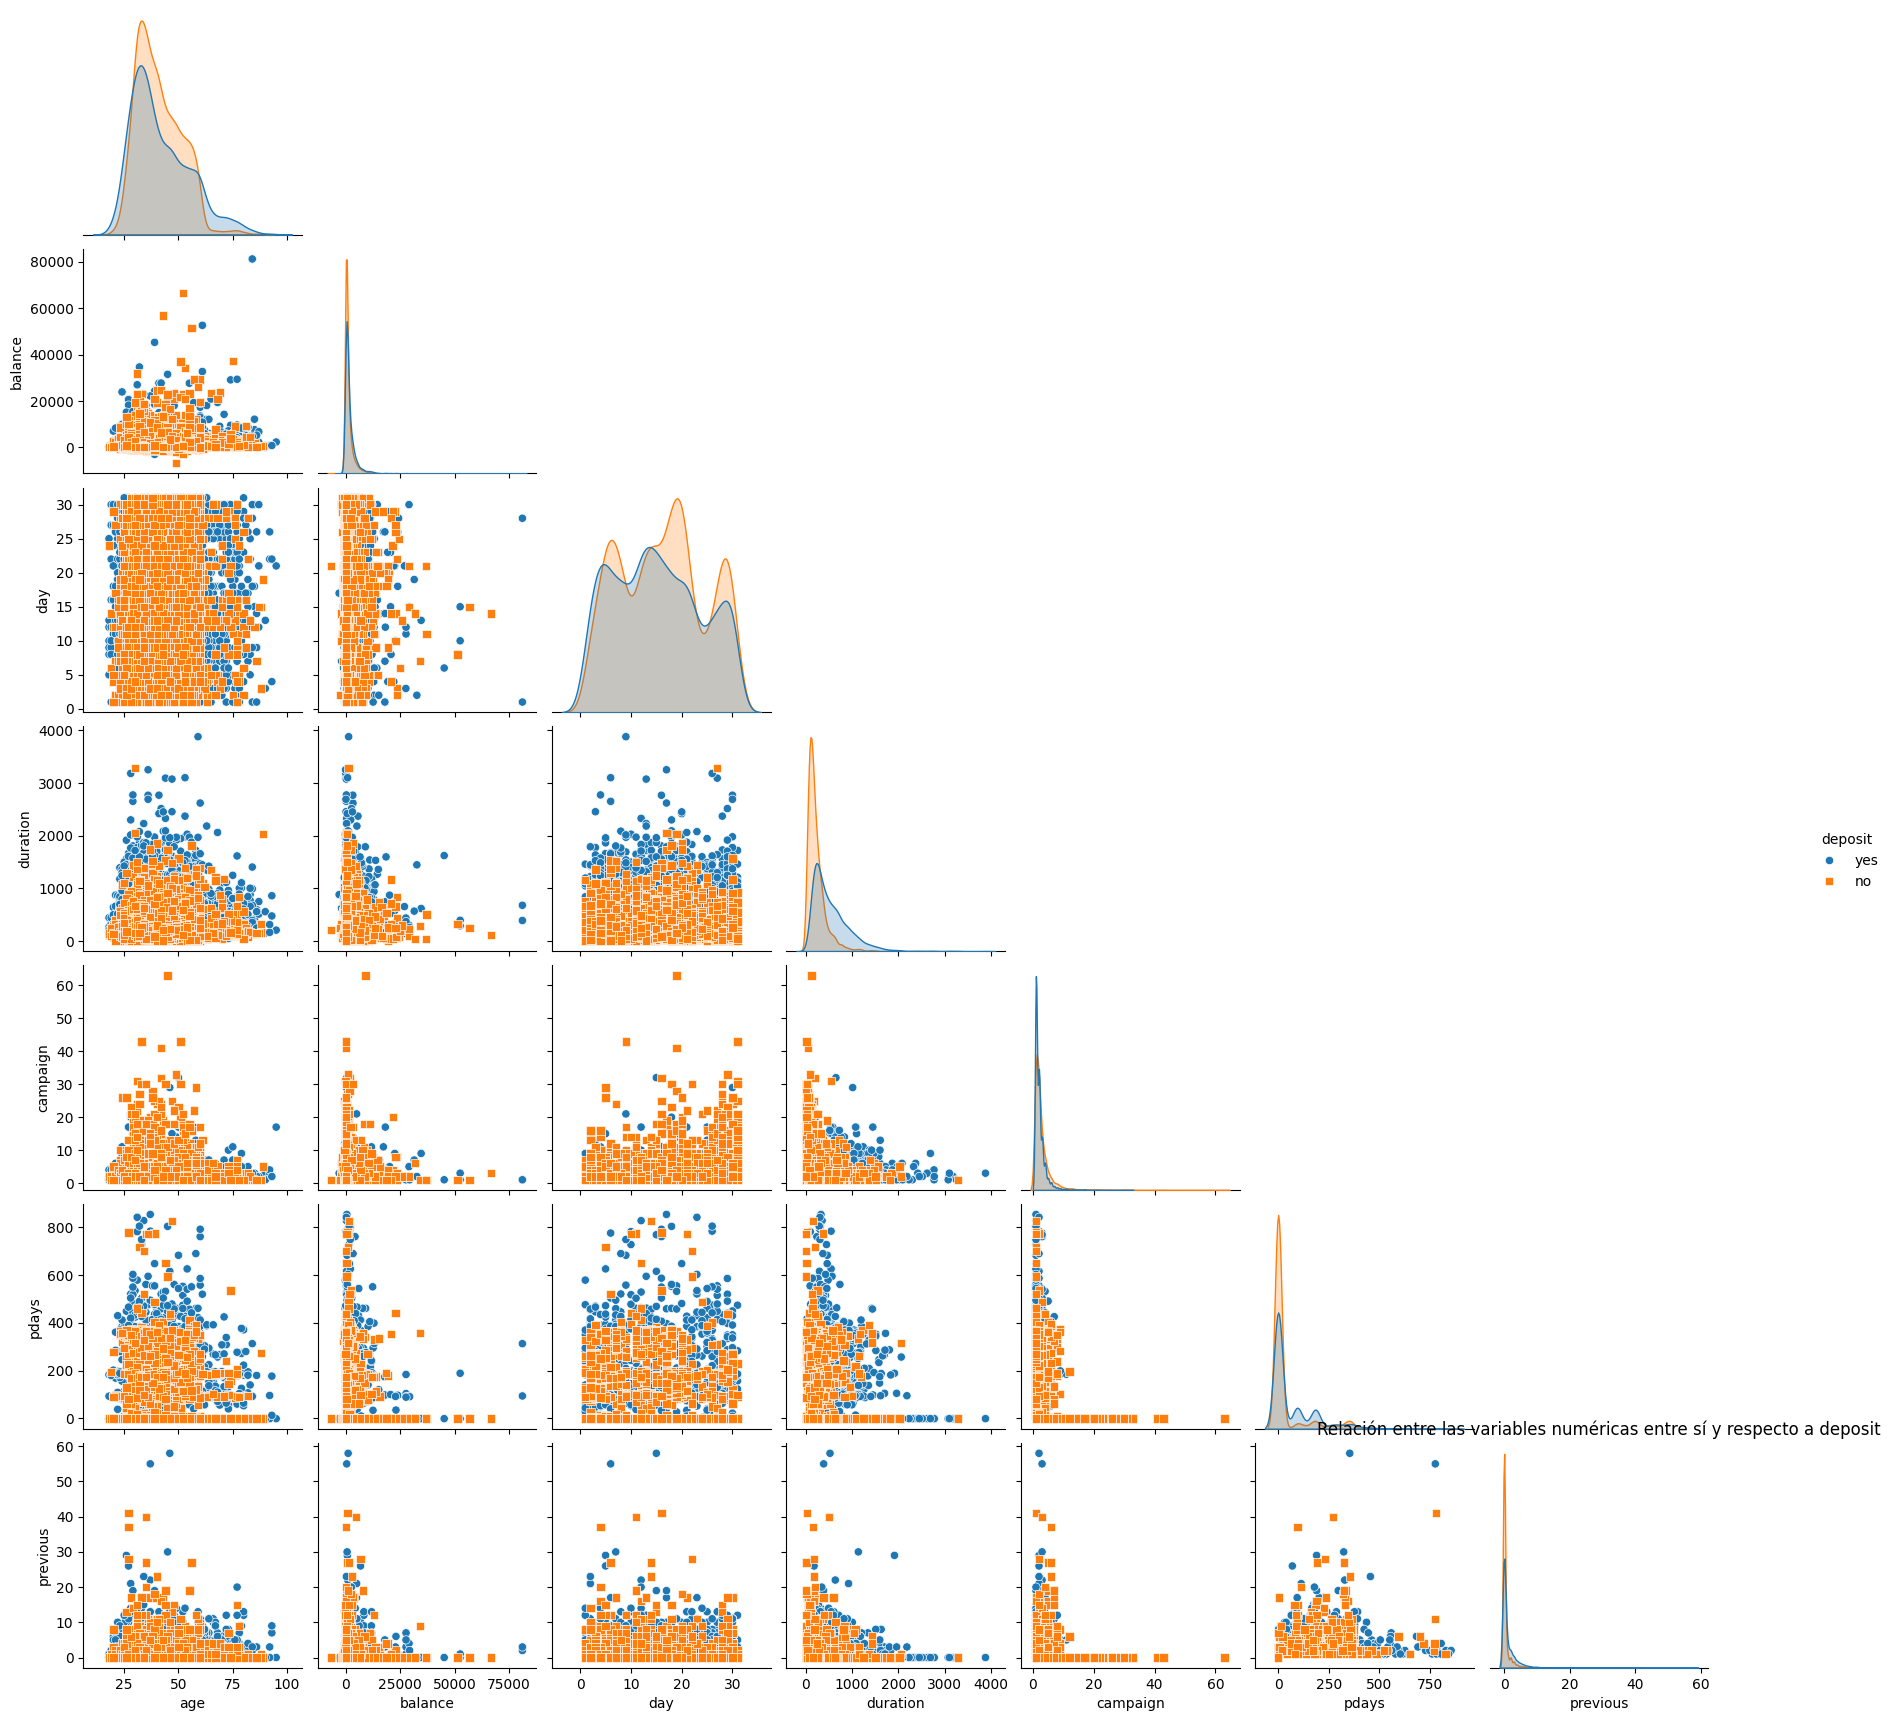

In [ ]:
plt.figure(figsize=(12, 6))
sns.pairplot(
    df,
    hue='deposit',
    markers=["o", "s"],
    corner="yes"
)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

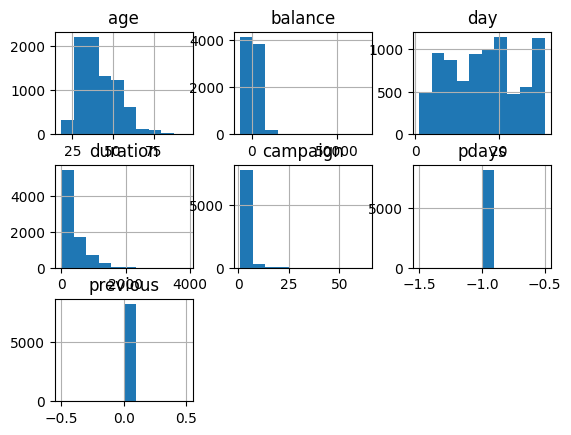

In [ ]:
# Definimos una máscara
not_previous_contact = df[df['pdays'] == -1]
not_previous_contact.hist()